# Cloudburst Prediction XAI (Explainable AI)
This notebook demonstrates how to use SHAP (SHapley Additive exPlanations) to interpret the XGBoost tabular model used in the main Skyris backend.

In [3]:
# Install required dependencies
# %pip install shap pandas numpy scikit-learn xgboost matplotlib joblib

import sys
import os
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure we can find the models and data directories relative to this notebook
BACKEND_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if BACKEND_DIR not in sys.path:
    sys.path.append(BACKEND_DIR)
print(f"Backend directory set to: {BACKEND_DIR}")

Backend directory set to: /home/ilesh-dhall/hackathons/skyris-graphethon/backend


## 1. Load Data & Prepare Scaler
We replicate the exact same preprocessing logic found in `api/inference.py` to ensure the SHAP values reflect real-world behavior.

In [5]:
# Load the dataset
data_path = os.path.join(BACKEND_DIR, 'data', 'sensor', 'cloudburst_dataset.csv')
df = pd.read_csv(data_path)

# Separate features & targets
X = df.drop(columns=["cloud_burst", "source_type"])
y = df["cloud_burst"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Fit Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert test set back to DataFrame so SHAP plots keep the column names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Loaded {len(df)} rows. Feature columns: {list(X.columns)}")

Loaded 10000 rows. Feature columns: ['Cloud_Top_Height', 'Cloud_Base_Height', 'Optical_Thickness', 'Rainfall', 'Humidity', 'Temperature', 'Pressure']


## 2. Load the Production XGBoost Model

In [6]:
model_path = os.path.join(BACKEND_DIR, 'models', 'xgboost_model.pkl')
xgb_model = joblib.load(model_path)

print("XGBoost Model loaded successfully.")

XGBoost Model loaded successfully.


/usr/lib/python3.12/pickle.py:1710: UserWarning: [06:24:37] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## 3. Initialize SHAP TreeExplainer
TreeExplainer is highly optimized for tree-based models like XGBoost and Random Forest.

In [7]:
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test_scaled_df.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)
print("Computed SHAP values.")

Computed SHAP values.


## 4. SHAP Summary Plot (Global Explainability)

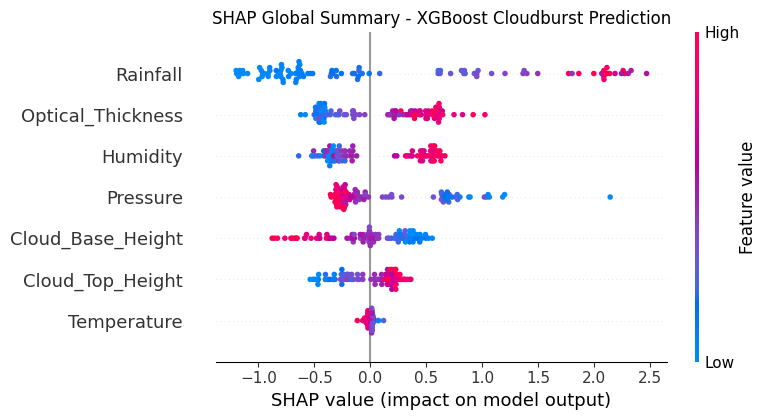

In [8]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Global Summary - XGBoost Cloudburst Prediction")
plt.tight_layout()
plt.show()

## 5. Local Explainability (Single Prediction)

Prediction Probability: 29.69%
   Cloud_Top_Height  Cloud_Base_Height  Optical_Thickness    Rainfall  \
0      17864.276695        2264.417875              13.94  150.839605   

    Humidity  Temperature   Pressure  
0  82.014446    23.954262  932.05071  


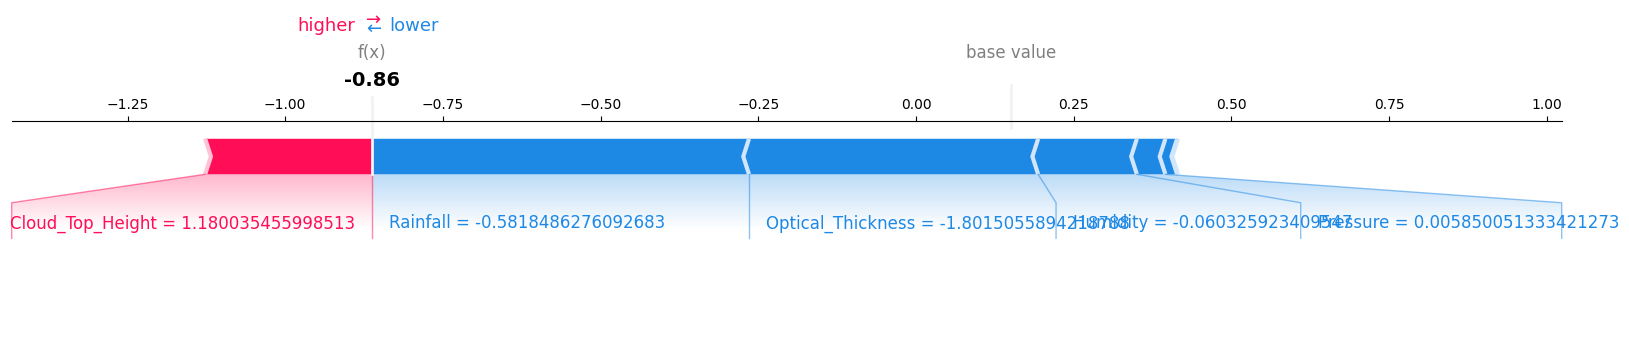

In [9]:
sample_idx = 5
test_sample = X_sample.iloc[[sample_idx]]
raw_sample_df = scaler.inverse_transform(test_sample)

pred_prob = xgb_model.predict_proba(test_sample)[0][1]
sample_shap_values = explainer.shap_values(test_sample)

feature_impacts = list(zip(X.columns, sample_shap_values[0]))
feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"Prediction Probability: {pred_prob * 100:.2f}%")
print(pd.DataFrame(raw_sample_df, columns=X.columns))

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    sample_shap_values[0],
    features=test_sample,
    feature_names=X.columns,
    matplotlib=True
)